<a href="https://colab.research.google.com/github/Fegel12/Unab/blob/main/3_2_Ejemplo_Modelo_crediticio_Parte_2_Fergel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



<img src="https://d1yjjnpx0p53s8.cloudfront.net/styles/logo-thumbnail/s3/102012/logo_unab.png?itok=hZ5x30O2" width="240" height="240" align="right"/>


# Modelo Crediticio (Regresión Logística) Parte 2


In [ ]:
#common packages
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np
sns.set()

# options
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
pd.options.display.max_columns = None

## models
from sklearn.linear_model import LogisticRegression
from sklearn import linear_model

## cross val and strat
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import train_test_split

# importing the random module
import random
from random import seed
from numpy.random import randint

#metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report as rep
import scipy.stats as stat
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

## Lectura de dataset

In [ ]:
X_train = pd.read_csv('https://raw.githubusercontent.com/JSebasB90/datasets/refs/heads/main/X_train_prepr.csv', index_col = 0)
y_train = pd.read_csv('https://raw.githubusercontent.com/JSebasB90/datasets/refs/heads/main/y_train_prepr.csv', index_col = 0)
X_test = pd.read_csv('https://raw.githubusercontent.com/JSebasB90/datasets/refs/heads/main/X_test_prepr.csv', index_col = 0)
y_test = pd.read_csv('https://raw.githubusercontent.com/JSebasB90/datasets/refs/heads/main/y_test_prepr.csv', index_col = 0)

In [ ]:
X_train.head()

,porcentaje_h_mayor_90,max_mora,porcentaje_h_60_90,porcentaje_h_pago_a_tiempo,porcentaje_h_30_60,porcentaje_h_1_30,min_mora,antiguedad,mora_de_30_60,mora_de_60_90,mora_mayor_90,regional,unidad_negocio,condicion_pago,centro_operacion,mora_de_1_30,mora_de_30_60:0,mora_de_30_60:1,mora_de_60_90:0,mora_de_60_90:1,mora_mayor_90:0,mora_mayor_90:1,regional:DC,regional:DN,regional:DS,regional:OC,unidad_negocio:ADM,unidad_negocio:CIL,unidad_negocio:GRN,unidad_negocio:OTRO NEGOCIO,condicion_pago:08D,condicion_pago:15D,condicion_pago:30D,condicion_pago:60D,condicion_pago:CTD,condicion_pago:OTRA CONDICION,centro_operacion:BELLO,centro_operacion:BUCARAMANGA,centro_operacion:CARTAGENA,centro_operacion:CHIQUINQUIRA,centro_operacion:CUCUTA,centro_operacion:MANIZALES,centro_operacion:OFICINA CENTRAL,centro_operacion:OTRO CENTRO,centro_operacion:PITALITO,centro_operacion:SIBERIA,centro_operacion:VILLANUEVA,centro_operacion:YUMBO,mora_de_1_30:0,mora_de_1_30:1,centro_operacion:VILLANUEVA_YUMBO_BELLO,centro_operacion:CARTAGENA_BUCARAMANGA,unidad_negocio:ADM_CIL,condicion_pago:30D_CTD,condicion_pago:OTRO,min_mora_factor,max_mora_factor,porcentaje_h_60_90_factor,porcentaje_h_60_90: entre 0 y 20,porcentaje_h_60_90: entre 20 y 80,porcentaje_h_60_90: entre 80 y 100,porcentaje_h_mayor_90_factor,porcentaje_h_30_60_factor,porcentaje_h_30_60: entre 0 y 30,porcentaje_h_30_60: entre 30 y 70,porcentaje_h_30_60: entre 70 y 100,Antiguedad_factor,antiguedad: menor a 6 meses,antiguedad: entre 6 meses y 1 año,antiguedad: entre 1 y 3 años,antiguedad: entre 3 y 5 años,antiguedad: entre 5 y 6 años,antiguedad: entre 6 y 8 años,antiguedad: entre 8 y 10 años,antiguedad: entre 10 y 12 años,antiguedad: mayor a 12 años,porcentaje_h_pago_a_tiempo_factor,porcentaje_h_1_30_factor,porcentaje_h_1_30: entre 0 y 25,porcentaje_h_1_30: entre 25 y 50,porcentaje_h_1_30: entre 50 y 75,porcentaje_h_1_30: entre 75 y 100
2289,0.00,68.0,0.43,85.95,0.43,13.16,-1097.0,2256,0,0,0,DC,ADM_CIL,15D,CARTAGENA_BUCARAMANGA,0,1,0,1,0,1,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,1,0,0,negativo,50,0 a 20,1,0,0,"(-0.1, 10.0]","(-0.1, 33.333]",1,0,0,entre 6 y 8 años,0,0,0,0,0,1,0,0,0,2,Entre 0 y 25,1,0,0,0
3218,0.00,71.0,1.30,39.44,22.62,36.62,-52.0,900,0,0,0,DC,GRN,OTRO,SIBERIA,0,1,0,1,0,1,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,negativo,50,0 a 20,1,0,0,"(-0.1, 10.0]","(-0.1, 33.333]",1,0,0,entre 1 y 3 años,0,0,1,0,0,0,0,0,0,2,Entre 25 y 50,0,1,0,0
2027,0.00,72.0,1.32,97.85,0.01,0.80,-40.0,19867,0,0,0,OC,ADM_CIL,30D o CTD,VILLANUEVA_YUMBO_BELLO,0,1,0,1,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,1,1,0,negativo,50,0 a 20,1,0,0,"(-0.1, 10.0]","(-0.1, 33.333]",1,0,0,mayor a 12 años,0,0,0,0,0,0,0,0,1,2,Entre 0 y 25,1,0,0,0
4081,14.28,114.0,14.28,0.00,71.42,0.00,46.0,1360,0,0,0,DC,ADM_CIL,30D o CTD,SIBERIA,0,1,0,1,0,1,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,1,0,no negativo,200,0 a 20,1,0,0,"(10.0, 20.0]","(66.667, 100.0]",0,0,1,entre 3 y 5 años,0,0,0,1,0,0,0,0,0,1,Entre 0 y 25,1,0,0,0
2378,32.66,172.0,6.53,6.52,16.33,37.94,-21.0,1586,0,0,1,DC,ADM_CIL,30D o CTD,CARTAGENA_BUCARAMANGA,0,1,0,1,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,1,1,0,negativo,200,0 a 20,1,0,0,"(30.0, 40.0]","(-0.1, 33.333]",1,0,0,entre 3 y 5 años,0,0,0,1,0,0,0,0,0,1,Entre 25 y 50,0,1,0,0


---

## Inputs

---

In [ ]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((6152, 82), (6152, 1), (1538, 82), (1538, 1))

In [ ]:
inputs_train_with_ref_cat = X_train.loc[: , [
                                             'mora_de_30_60:0',
                                             'mora_de_30_60:1',
                                             'mora_de_60_90:0',
                                             'mora_de_60_90:1',
                                             'mora_mayor_90:0',
                                             'mora_mayor_90:1',
                                             'regional:DC',
                                             'regional:DN',
                                             'regional:DS',
                                             'regional:OC',
                                             'unidad_negocio:GRN',
                                             'unidad_negocio:OTRO NEGOCIO',
                                             'condicion_pago:08D',
                                             'condicion_pago:15D',
                                             'centro_operacion:CHIQUINQUIRA',
                                             'centro_operacion:CUCUTA',
                                             'centro_operacion:MANIZALES',
                                             'centro_operacion:SIBERIA',
                                             'centro_operacion:VILLANUEVA_YUMBO_BELLO',
                                             'centro_operacion:CARTAGENA_BUCARAMANGA',
                                             'unidad_negocio:ADM_CIL',
                                             'condicion_pago:30D_CTD',
                                             'condicion_pago:OTRO',
                                             'porcentaje_h_60_90: entre 0 y 20',
                                             'porcentaje_h_60_90: entre 20 y 80',
                                             'porcentaje_h_60_90: entre 80 y 100',
                                             'porcentaje_h_30_60: entre 0 y 30',
                                             'porcentaje_h_30_60: entre 30 y 70',
                                             'porcentaje_h_30_60: entre 70 y 100',
                                             'antiguedad: menor a 6 meses',
                                             'antiguedad: entre 6 meses y 1 año',
                                             'antiguedad: entre 1 y 3 años',
                                             'antiguedad: entre 3 y 5 años',
                                             'antiguedad: entre 5 y 6 años',
                                             'antiguedad: entre 6 y 8 años',
                                             'antiguedad: entre 8 y 10 años',
                                             'antiguedad: entre 10 y 12 años',
                                             'antiguedad: mayor a 12 años',
                                             'porcentaje_h_1_30: entre 0 y 25',
                                             'porcentaje_h_1_30: entre 25 y 50',
                                             'porcentaje_h_1_30: entre 50 y 75',
                                             'porcentaje_h_1_30: entre 75 y 100'
]]

In [ ]:
# Here we select a limited set of input variables in a new dataframe.
inputs_test_with_ref_cat = X_test.loc[: , [
                                             'mora_de_30_60:0',
                                             'mora_de_30_60:1',
                                             'mora_de_60_90:0',
                                             'mora_de_60_90:1',
                                             'mora_mayor_90:0',
                                             'mora_mayor_90:1',
                                             'regional:DC',
                                             'regional:DN',
                                             'regional:DS',
                                             'regional:OC',
                                             'unidad_negocio:GRN',
                                             'unidad_negocio:OTRO NEGOCIO',
                                             'condicion_pago:08D',
                                             'condicion_pago:15D',
                                             'centro_operacion:CHIQUINQUIRA',
                                             'centro_operacion:CUCUTA',
                                             'centro_operacion:MANIZALES',
                                             'centro_operacion:SIBERIA',
                                             'centro_operacion:VILLANUEVA_YUMBO_BELLO',
                                             'centro_operacion:CARTAGENA_BUCARAMANGA',
                                             'unidad_negocio:ADM_CIL',
                                             'condicion_pago:30D_CTD',
                                             'condicion_pago:OTRO',
                                             'porcentaje_h_60_90: entre 0 y 20',
                                             'porcentaje_h_60_90: entre 20 y 80',
                                             'porcentaje_h_60_90: entre 80 y 100',
                                             'porcentaje_h_30_60: entre 0 y 30',
                                             'porcentaje_h_30_60: entre 30 y 70',
                                             'porcentaje_h_30_60: entre 70 y 100',
                                             'antiguedad: menor a 6 meses',
                                             'antiguedad: entre 6 meses y 1 año',
                                             'antiguedad: entre 1 y 3 años',
                                             'antiguedad: entre 3 y 5 años',
                                             'antiguedad: entre 5 y 6 años',
                                             'antiguedad: entre 6 y 8 años',
                                             'antiguedad: entre 8 y 10 años',
                                             'antiguedad: entre 10 y 12 años',
                                             'antiguedad: mayor a 12 años',
                                             'porcentaje_h_1_30: entre 0 y 25',
                                             'porcentaje_h_1_30: entre 25 y 50',
                                             'porcentaje_h_1_30: entre 50 y 75',
                                             'porcentaje_h_1_30: entre 75 y 100'
]]

In [ ]:
inputs_train_with_ref_cat.shape, inputs_test_with_ref_cat.shape

((6152, 42), (1538, 42))

**Descripción previa:**

|Variable	| Tipo	| IV |	Menor WoE |
|--------|-------|----|--------|
|mora_de_30_60 |	Categorica |	0.05 |	1
|mora_de_60_90 |	Categorica |	0.05 |	1
|mora_mayor_90 |	Categorica |	0.06 |	1
|mora_de_1_30 |	Categorica |	0.01 |	0
|regional |	Categorica |	0.05 |	DC
|unidad_negocio	| Categorica |	0.25 |	OTRO NEGOCIO
|condicion_pago |	Categorica |	0.13 |	30 o CTD
|centro_operacion	| Categorica	| 0.11 |	SIBERIA
|min_mora |	Numerica |	0.57	| no negativo
|max_mora |	Numerica |	1.46	| 300
|porcentaje_h_60_90 |	Numerica |	0.46 |	80 a 100
|porcentaje_h_mayor_90 |	Numerica |	1.52	| (50,100]
|porcentaje_h_30_60 |	Numerica |	0.39 |	entre 70 y 100
|antiguedad |	Numerica |	0.22 | 	entre 3 y 5 años
|porcentaje_h_pago_a_tiempo |	Numerica |	0.56	| 0
|porcentaje_h_1_30 |	Numerica |	0.46	| Entre 0 y 25


In [ ]:
# Here we store the names of the reference category dummy variables in a list.
ref_categories = [
                  'mora_de_30_60:1',
                  'mora_de_60_90:1',
                  'mora_mayor_90:1',
                  'regional:DC',
                  'unidad_negocio:OTRO NEGOCIO',
                  'centro_operacion:SIBERIA',
                  'condicion_pago:30D_CTD',
                  'porcentaje_h_60_90: entre 80 y 100',
                  'porcentaje_h_30_60: entre 70 y 100',
                  'antiguedad: entre 3 y 5 años',
                  'porcentaje_h_1_30: entre 0 y 25'
                  ]

In [ ]:
inputs_train = inputs_train_with_ref_cat.drop(ref_categories, axis = 1)
inputs_test = inputs_test_with_ref_cat.drop(ref_categories, axis = 1)

#inputs_test = inputs_test_with_ref_cat.drop(ref_categories, axis = 1)

# From the dataframe with input variables, we drop the variables with variable names in the list with reference categories.
inputs_train.sample(5)

,mora_de_30_60:0,mora_de_60_90:0,mora_mayor_90:0,regional:DN,regional:DS,regional:OC,unidad_negocio:GRN,condicion_pago:08D,condicion_pago:15D,centro_operacion:CHIQUINQUIRA,centro_operacion:CUCUTA,centro_operacion:MANIZALES,centro_operacion:VILLANUEVA_YUMBO_BELLO,centro_operacion:CARTAGENA_BUCARAMANGA,unidad_negocio:ADM_CIL,condicion_pago:OTRO,porcentaje_h_60_90: entre 0 y 20,porcentaje_h_60_90: entre 20 y 80,porcentaje_h_30_60: entre 0 y 30,porcentaje_h_30_60: entre 30 y 70,antiguedad: menor a 6 meses,antiguedad: entre 6 meses y 1 año,antiguedad: entre 1 y 3 años,antiguedad: entre 5 y 6 años,antiguedad: entre 6 y 8 años,antiguedad: entre 8 y 10 años,antiguedad: entre 10 y 12 años,antiguedad: mayor a 12 años,porcentaje_h_1_30: entre 25 y 50,porcentaje_h_1_30: entre 50 y 75,porcentaje_h_1_30: entre 75 y 100
166,1,1,1,0,0,0,0,1,0,0,0,0,1,0,1,0,1,0,1,0,0,0,0,0,0,1,0,0,1,0,0
5510,1,1,1,0,1,0,1,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0
2734,1,1,1,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0
2376,1,1,1,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0
5159,1,1,1,1,0,0,1,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,1,0,0


In [ ]:
inputs_train.shape, inputs_test.shape

((6152, 31), (1538, 31))

---

## Primer modelo con p-valores

---

In [ ]:
# P values for sklearn logistic regression.
# Class to display p-values for logistic regression in sklearn.

class LogisticRegression_with_p_values:

    def __init__(self,*args,**kwargs):#,**kwargs):
        self.model = linear_model.LogisticRegression(*args,**kwargs)#,**args)

    def fit(self,X,y):
        self.model.fit(X,y)

        #### Get p-values for the fitted model ####
        denom = (2.0 * (1.0 + np.cosh(self.model.decision_function(X))))
        denom = np.tile(denom,(X.shape[1],1)).T
        F_ij = np.dot((X / denom).T,X) ## Fisher Information Matrix
        Cramer_Rao = np.linalg.inv(F_ij) ## Inverse Information Matrix
        sigma_estimates = np.sqrt(np.diagonal(Cramer_Rao))
        z_scores = self.model.coef_[0] / sigma_estimates # z-score for eaach model coefficient
        p_values = [stat.norm.sf(abs(x)) * 2 for x in z_scores] ### two tailed test for p-values

        self.coef_ = self.model.coef_
        self.intercept_ = self.model.intercept_
        self.p_values = p_values

In [ ]:
# Logistic regression with balansed weights
reg = LogisticRegression_with_p_values(class_weight='balanced')
reg.fit(inputs_train, y_train)
# Estimates the coefficients of the object from the 'LogisticRegression' class
# with inputs (independent variables) contained in the first dataframe
# and targets (dependent variables) contained in the second dataframe.
feature_name = inputs_train.columns.values

In [ ]:
summary_table = pd.DataFrame(columns = ['Feature name'], data = feature_name)
summary_table['Coefficients'] = np.transpose(reg.coef_)
summary_table.index = summary_table.index + 1
summary_table.loc[0] = ['Intercept', reg.intercept_[0]]
summary_table = summary_table.sort_index()
#summary_table = summary_table.sort_values(by='Coefficients', ascending=False)
summary_table

,Feature name,Coefficients
0,Intercept,-8.983375
1,mora_de_30_60:0,0.324551
2,mora_de_60_90:0,0.401849
3,mora_mayor_90:0,0.317379
4,regional:DN,0.036280
5,regional:DS,0.331685
6,regional:OC,0.541529
7,unidad_negocio:GRN,0.463808
8,condicion_pago:08D,0.837638
9,condicion_pago:15D,0.645880


In [ ]:
# This is a list.
p_values = reg.p_values
# We take the result of the newly added method 'p_values' and store it in a variable 'p_values'.
# Add the intercept for completeness.
p_values = np.append(np.nan, np.array(p_values))
# We add the value 'NaN' in the beginning of the variable with p-values.
summary_table['p_values'] = p_values
# In the 'summary_table' dataframe, we add a new column, called 'p_values', containing the values from the 'p_values' variable.
summary_table

,Feature name,Coefficients,p_values
0,Intercept,-8.983375,NaN
1,mora_de_30_60:0,0.324551,3.631266e-02
2,mora_de_60_90:0,0.401849,5.415376e-02
3,mora_mayor_90:0,0.317379,3.094592e-02
4,regional:DN,0.036280,7.587931e-01
5,regional:DS,0.331685,7.991521e-03
6,regional:OC,0.541529,2.312778e-03
7,unidad_negocio:GRN,0.463808,8.833591e-03
8,condicion_pago:08D,0.837638,6.308709e-11
9,condicion_pago:15D,0.645880,6.735966e-05


No se encuentra ninguna variable que no sea trascendente por medio de la regresión logística.

In [ ]:
# Same as above.
p_values = reg.p_values
p_values = np.append(np.nan,np.array(p_values))
summary_table['p_values'] = p_values
summary_table

,Feature name,Coefficients,p_values
0,Intercept,-8.983375,NaN
1,mora_de_30_60:0,0.324551,3.631266e-02
2,mora_de_60_90:0,0.401849,5.415376e-02
3,mora_mayor_90:0,0.317379,3.094592e-02
4,regional:DN,0.036280,7.587931e-01
5,regional:DS,0.331685,7.991521e-03
6,regional:OC,0.541529,2.312778e-03
7,unidad_negocio:GRN,0.463808,8.833591e-03
8,condicion_pago:08D,0.837638,6.308709e-11
9,condicion_pago:15D,0.645880,6.735966e-05


Esto se hace inicialmente solo por saber (último intento) de descartar instancias.

---

## Segundo modelo (ajuste de hiper-parámetros)

---

Vamos a seleccionar cada uno de los hiperparametros, eligiendo el que tenga mejor rendimiento en el F1-score.

Ver [Métodos de selección de Hiperparametros](https://metodotrading.com/hiperparametros/) y [LogisticRegression](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LogisticRegression.html)

**F1-score:** La puntuación F1 *es una métrica que mide la exactitud del modelo cuando las clases están desequilibradas, centrándose en la exactitud de las predicciones positivas y los registros de positivos reales. Se puede ver la exactitud con la que el modelo captura los resultados que importan.* La métrica busca equilibrar la exhaustividad y la precisión para tratar de encontrar algo que idealmente esté en el medio entre esos dos. Tenga en cuenta que cuanto más desequilibrado esté un conjunto de datos, menor será la puntuación F1, incluso con la misma exactitud general.

Si el valor de F1 es alto, todas las demás métricas de puntuación serán altas. Si el valor es bajo, es una señal de que necesita hacer más análisis. No obstante, si la puntuación es muy alta, o si la puntuación de retención es mucho más baja que la puntuación de validación cruzada, podría ser una señal de fuga de datos.

F1 se calcula de la siguiente manera: 2 x ((Precisión x Exhaustividad) / (Precisión + Exhaustividad))

### max_iter

- **max_iter (default=100):** Número máximo de iteraciones necesarias para que los solucionadores converjan.

In [ ]:
### #  define function to get the n_estimators
def get_n_iterations(X_train, X_test, y_train, y_test, r_min=1, r_max= 2000):

    results = []

    for n_iter in (range(r_min, r_max, 50)):

        F1_SCORE_TRAIN = []
        F1_SCORE_TEST = []
        x = {}
        # define the regressor model
        model = LogisticRegression(max_iter = n_iter,
                                   random_state = 1727,
                                   verbose=False)

        # fit the model with the training data
        # max_iter: int, default=100::: Maximum number of iterations taken for the solvers to converge.
        # verbose: int, default=0:: For the liblinear and lbfgs solvers set verbose to any positive number for verbosity.
        # random_state: int, RandomState instance, default=None:: Used when solver == ‘sag’, ‘saga’ or ‘liblinear’ to shuffle the data. See Glossary for details.

        model.fit(X_train, y_train)

        # Appending F1 scores to empty list calculated using the predictions
        model_train = model.predict(X_train)
        model_test = model.predict(X_test)

#        auc_score=roc_auc_score(y_test, test_preds)
        f1_score_train = f1_score(model_train,y_train)
        f1_score_test = f1_score(model_test,y_test)

        # get the f1 on train and valid

        F1_SCORE_TRAIN.append(f1_score_train)
        F1_SCORE_TEST.append(f1_score_test)

        # calculate the mean F1 on train and valid data

        mean_f1_train = np.mean(F1_SCORE_TRAIN)
        mean_f1_test = np.mean(F1_SCORE_TEST)
        x['iterations'] = n_iter
        x['train_f1'] = mean_f1_train
        x['test_f1'] = mean_f1_test
        results.append(x)

        print('With N_ITERATIONS:\t'+ str(n_iter) + '\tMEAN F1 TRAIN:\t' + str(mean_f1_train)+ '\tMEAN F1 TEST: '+str(mean_f1_test))


    return pd.DataFrame.from_dict(results)

In [ ]:
# train model for n_estimators value 100 to 1800 with a gap of 100 estimators at each iteration.
iterations_result = get_n_iterations(inputs_train, inputs_test, y_train, y_test,r_min=1, r_max=500)

With N_ITERATIONS:	1	MEAN F1 TRAIN:	0.8596848934198332	MEAN F1 TEST: 0.859896219421794
With N_ITERATIONS:	51	MEAN F1 TRAIN:	0.8909235668789809	MEAN F1 TEST: 0.8877388535031847
With N_ITERATIONS:	101	MEAN F1 TRAIN:	0.8909235668789809	MEAN F1 TEST: 0.8877388535031847
With N_ITERATIONS:	151	MEAN F1 TRAIN:	0.8909235668789809	MEAN F1 TEST: 0.8877388535031847
With N_ITERATIONS:	201	MEAN F1 TRAIN:	0.8909235668789809	MEAN F1 TEST: 0.8877388535031847
With N_ITERATIONS:	251	MEAN F1 TRAIN:	0.8909235668789809	MEAN F1 TEST: 0.8877388535031847
With N_ITERATIONS:	301	MEAN F1 TRAIN:	0.8909235668789809	MEAN F1 TEST: 0.8877388535031847
With N_ITERATIONS:	351	MEAN F1 TRAIN:	0.8909235668789809	MEAN F1 TEST: 0.8877388535031847
With N_ITERATIONS:	401	MEAN F1 TRAIN:	0.8909235668789809	MEAN F1 TEST: 0.8877388535031847
With N_ITERATIONS:	451	MEAN F1 TRAIN:	0.8909235668789809	MEAN F1 TEST: 0.8877388535031847


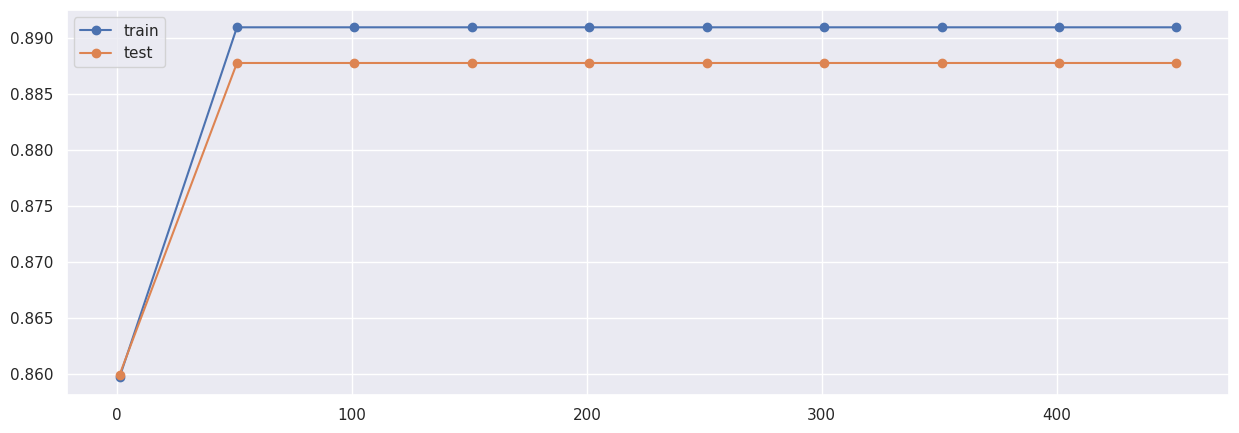

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(iterations_result['iterations'], iterations_result['train_f1'], marker='o', label= 'train')
plt.plot(iterations_result['iterations'], iterations_result['test_f1'], marker='o', label= 'test')
plt.legend();

Vamos a elegir **max_iter: 50**

### Solver

- **solver: (default = ‘lbfgs’):**  Algoritmo a utilizar en el problema de optimización. Para elegir un solucionador, es posible que desee considerar los siguientes aspectos:

  - Para conjuntos de datos pequeños, ‘liblinear’ es una buena opción, mientras que ‘sag’ y ‘saga’ son más rápidos para los grandes;

  - Para problemas multiclase, solo ‘newton-cg’, ‘sag’, ‘saga’ y ‘lbfgs’ manejan la pérdida multinomial;

  - ‘liblinear’ y ‘newton-cholesky’ solo pueden manejar la clasificación binaria de manera predeterminada. Para aplicar un esquema de uno contra resto para la configuración multiclase, se puede encapsular con OneVsRestClassifier.

  - ‘Newton-Cholesky’ es una buena opción para n_samples >> n_features, especialmente con características categóricas codificadas one-hot con categorías poco frecuentes. Tenga en cuenta que el uso de memoria de este solucionador tiene una dependencia cuadrática de n_features porque calcula explícitamente la matriz hessiana.

In [ ]:
#  define function to get the n_estimators
def get_solver(X_train, X_test, y_train, y_test):

    results = []
    solvers = ['lbfgs', 'sag', 'saga', 'newton-cg','liblinear']

    for solver in solvers:

        F1_SCORE_TRAIN = []
        F1_SCORE_TEST = []
        x = {}
        # define the regressor model
        model = LogisticRegression(max_iter = 50, # el elegido previamente
                                   solver = solver,
                                   random_state = 1727,
                                   verbose=False)

        # fit the model with the training data

        model.fit(X_train, y_train)

        # Appending F1 scores to empty list calculated using the predictions
        model_train = model.predict(X_train)
        model_test = model.predict(X_test)

        f1_score_train = f1_score(model_train,y_train)
        f1_score_test = f1_score(model_test,y_test)

        # get the rmsle on train and valid

        F1_SCORE_TRAIN.append(f1_score_train)
        F1_SCORE_TEST.append(f1_score_test)

        # calculate the mean F1 on train and valid data

        mean_f1_train = np.mean(F1_SCORE_TRAIN)
        mean_f1_test = np.mean(F1_SCORE_TEST)
        x['solver'] = solver
        x['train_f1'] = mean_f1_train
        x['test_f1'] = mean_f1_test
        results.append(x)

        print('With N_ITERATIONS:\t'+ str(solver) + '\tMEAN F1 TRAIN:\t' + str(mean_f1_train)+ '\tMEAN F1 TEST: '+str(mean_f1_test))

    return pd.DataFrame.from_dict(results)

In [ ]:
# train model for n_estimators value 100 to 1800 with a gap of 100 estimators at each iteration.
solver_result = get_solver(inputs_train, inputs_test, y_train, y_test)

With N_ITERATIONS:	lbfgs	MEAN F1 TRAIN:	0.8909235668789809	MEAN F1 TEST: 0.8877388535031847
With N_ITERATIONS:	sag	MEAN F1 TRAIN:	0.8909669717469161	MEAN F1 TEST: 0.8877388535031847
With N_ITERATIONS:	saga	MEAN F1 TRAIN:	0.8909669717469161	MEAN F1 TEST: 0.8877388535031847
With N_ITERATIONS:	newton-cg	MEAN F1 TRAIN:	0.890856631180977	MEAN F1 TEST: 0.8877388535031847
With N_ITERATIONS:	liblinear	MEAN F1 TRAIN:	0.8910989557434112	MEAN F1 TEST: 0.8878281622911695


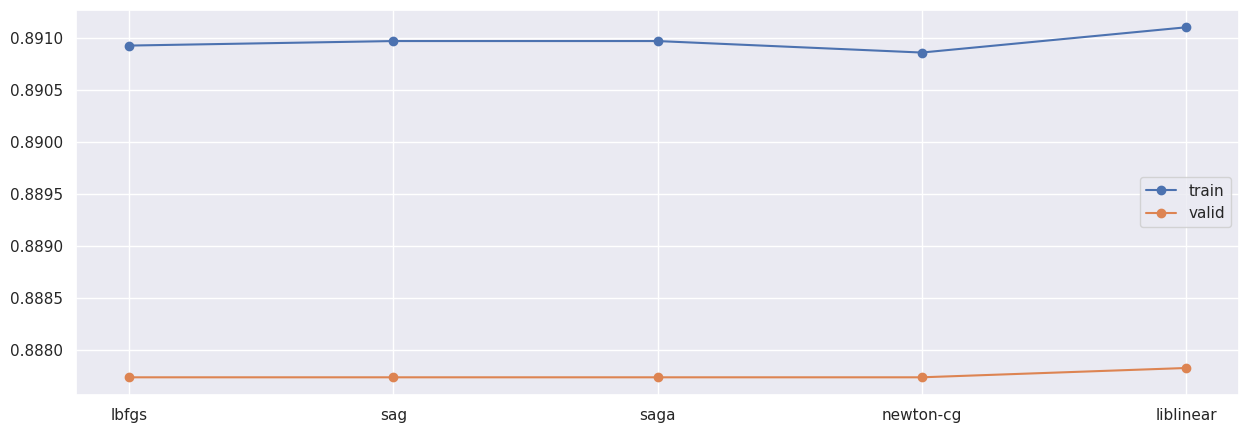

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(solver_result['solver'], solver_result['train_f1'], marker='o', label= 'train')
plt.plot(solver_result['solver'], solver_result['test_f1'], marker='o', label= 'valid')
plt.legend();

La mejor opción es **liblinear**.

### Inverse of Regularization strength (c)

- **c (default=1.0):** es el inverso de la fuerza de regularización; debe ser un valor flotante positivo.

  Al igual que en las máquinas de vectores de soporte, los valores más pequeños especifican una regularización más fuerte.

In [ ]:
#  define function to get the n_estimators
def get_C(X_train, X_test, y_train, y_test):

    results = []
    logisticregression__C = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5, 10, 100, 200, 300, 400, 500, 1000, 2000, 3000, 4000, 10000]

    for inv_reg in logisticregression__C:

        F1_SCORE_TRAIN = []
        F1_SCORE_TEST = []
        x = {}
        # define the regressor model
        model = LogisticRegression(max_iter = 50, #obtenido
                                   solver = 'liblinear', #obtenido
                                   C = inv_reg,
                                   random_state = 1727,
                                   verbose=False)

        # fit the model with the training data

        model.fit(X_train, y_train)

        # Appending F1 scores to empty list calculated using the predictions
        model_train = model.predict(X_train)
        model_test = model.predict(X_test)

        f1_score_train = f1_score(model_train,y_train)
        f1_score_test = f1_score(model_test,y_test)

        # get the rmsle on train and valid

        F1_SCORE_TRAIN.append(f1_score_train)
        F1_SCORE_TEST.append(f1_score_test)

        # calculate the mean F1 on train and valid data

        mean_f1_train = np.mean(F1_SCORE_TRAIN)
        mean_f1_test = np.mean(F1_SCORE_TEST)
        x['inv_reg'] = inv_reg
        x['train_f1'] = mean_f1_train
        x['test_f1'] = mean_f1_test
        results.append(x)

        print('For the Inverse Regularization Strenght:\t'+ str(inv_reg) + '\tMEAN F1 TRAIN:\t' + str(mean_f1_train)+ '\tMEAN F1 VALID: '+str(mean_f1_test))

    return pd.DataFrame.from_dict(results)

In [ ]:
# train model for n_estimators value 100 to 1800 with a gap of 100 estimators at each iteration.
inv_reg_result = get_C(inputs_train, inputs_test, y_train, y_test)

For the Inverse Regularization Strenght:	0.001	MEAN F1 TRAIN:	0.859923982571614	MEAN F1 VALID: 0.859896219421794
For the Inverse Regularization Strenght:	0.01	MEAN F1 TRAIN:	0.8763250883392226	MEAN F1 VALID: 0.8753335874952345
For the Inverse Regularization Strenght:	0.05	MEAN F1 TRAIN:	0.8850698174006445	MEAN F1 VALID: 0.8809988294966836
For the Inverse Regularization Strenght:	0.1	MEAN F1 TRAIN:	0.8867701985453116	MEAN F1 VALID: 0.8833922261484098
For the Inverse Regularization Strenght:	0.5	MEAN F1 TRAIN:	0.8907429479539134	MEAN F1 VALID: 0.8875645609853
For the Inverse Regularization Strenght:	1.0	MEAN F1 TRAIN:	0.8910989557434112	MEAN F1 VALID: 0.8878281622911695
For the Inverse Regularization Strenght:	5	MEAN F1 TRAIN:	0.8909669717469161	MEAN F1 VALID: 0.8878281622911695
For the Inverse Regularization Strenght:	10	MEAN F1 TRAIN:	0.8906358841675789	MEAN F1 VALID: 0.8870326173428799
For the Inverse Regularization Strenght:	100	MEAN F1 TRAIN:	0.8903045988453115	MEAN F1 VALID: 0.8873

In [ ]:
inv_reg_result[inv_reg_result['test_f1']==inv_reg_result['test_f1'].max()]

,inv_reg,train_f1,test_f1
5,1.0,0.891099,0.887828
6,5.0,0.890967,0.887828


Escogemos c=1.0

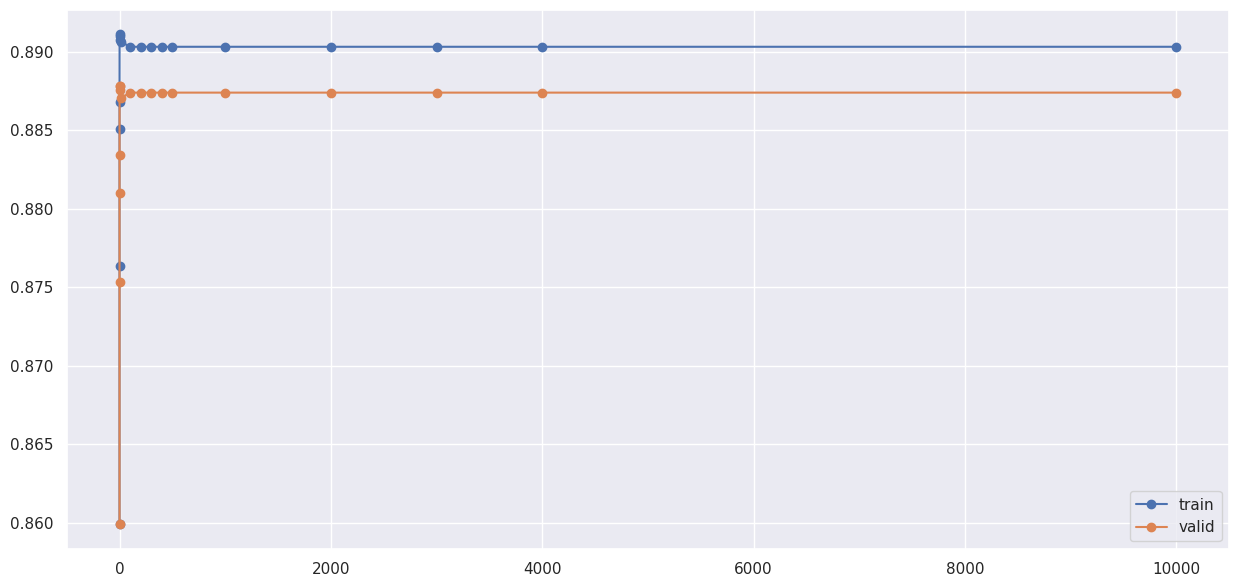

In [ ]:
plt.figure(figsize=(15,7))
plt.plot(inv_reg_result['inv_reg'], inv_reg_result['train_f1'], marker='o', label= 'train')
plt.plot(inv_reg_result['inv_reg'], inv_reg_result['test_f1'], marker='o', label= 'valid')
plt.legend();

### Class weight

- **class weight (dict or ‘balanced’, default=None):** Pesos asociados a las clases en la forma {class_label: weight}. Si no se proporciona, se supone que todas las clases tienen un peso de uno.

  - El modo "balanceado" utiliza los valores de y para ajustar automáticamente los pesos de manera inversamente proporcional a las frecuencias de clase en los datos de entrada como n_samples / (n_classes * np.bincount(y)).

  Tenga en cuenta que estos pesos se multiplicarán por sample_weight (que se pasa a través del método de ajuste) si se especifica sample_weight.

In [ ]:
#  define function to get the n_estimators
# este codigo explora el efecto de diferentes pesos de clase en el modelo
def get_class_weigh(X_train, X_test, y_train, y_test):

    results = []
    weights = list(np.linspace(0.3,0.9,100)) #rango donde itera cw  #esos valores pueden mudar? estaban 0.5 a 0.9

    for cw in weights:

        F1_SCORE_TRAIN = []
        F1_SCORE_TEST = []
        x = {}
        # define the regressor model
        model = LogisticRegression(max_iter = 50,
                                   solver = 'liblinear', #elegido previamente
                                   C = 1,  # elegido
                                   class_weight={0:1-cw, 1:cw},
                                   random_state = 1727,
                                   verbose=False)

        # fit the model with the training data

        model.fit(X_train, y_train)

        # Appending F1 scores to empty list calculated using the predictions
        model_train = model.predict(X_train)
        model_test = model.predict(X_test)

        f1_score_train = f1_score(model_train,y_train)
        f1_score_test = f1_score(model_test,y_test)

        # get the rmsle on train and valid

        F1_SCORE_TRAIN.append(f1_score_train)
        F1_SCORE_TEST.append(f1_score_test)

        # calculate the mean F1 on train and valid data

        mean_f1_train = np.mean(F1_SCORE_TRAIN)
        mean_f1_test = np.mean(F1_SCORE_TEST)
        x['class_weight'] = cw
        x['train_f1'] = mean_f1_train
        x['test_f1'] = mean_f1_test
        results.append(x)

        print('With the weight:\t'+ str(cw) + '\tMEAN F1 TRAIN:\t' + str(mean_f1_train)+ '\tMEAN F1 VALID: '+str(mean_f1_test))

    return pd.DataFrame.from_dict(results)

In [ ]:
# train model for n_estimators value 100 to 1800 with a gap of 100 estimators at each iteration.
class_weigh_result = get_class_weigh(inputs_train, inputs_test, y_train, y_test)

With the weight:	0.3	MEAN F1 TRAIN:	0.8632842334969995	MEAN F1 VALID: 0.8709677419354839
With the weight:	0.30606060606060603	MEAN F1 TRAIN:	0.8663334057813519	MEAN F1 VALID: 0.8745115067303517
With the weight:	0.31212121212121213	MEAN F1 TRAIN:	0.8674620390455532	MEAN F1 VALID: 0.8757037678648766
With the weight:	0.3181818181818182	MEAN F1 TRAIN:	0.8689252083558827	MEAN F1 VALID: 0.8762975778546713
With the weight:	0.3242424242424242	MEAN F1 TRAIN:	0.8699687061616489	MEAN F1 VALID: 0.8748921484037964
With the weight:	0.3303030303030303	MEAN F1 TRAIN:	0.8707629398471968	MEAN F1 VALID: 0.8761251607372482
With the weight:	0.33636363636363636	MEAN F1 TRAIN:	0.8737947289479323	MEAN F1 VALID: 0.8777777777777778
With the weight:	0.3424242424242424	MEAN F1 TRAIN:	0.874251497005988	MEAN F1 VALID: 0.8794205368555603
With the weight:	0.3484848484848485	MEAN F1 TRAIN:	0.8742796157950907	MEAN F1 VALID: 0.8798301486199576
With the weight:	0.35454545454545455	MEAN F1 TRAIN:	0.8755456190780369	MEAN F

In [ ]:
class_weigh_result[class_weigh_result['test_f1']==class_weigh_result['test_f1'].max()]

,class_weight,train_f1,test_f1
24,0.445455,0.891251,0.896721


La mejor opción es 0.445455 y 1-0.445455

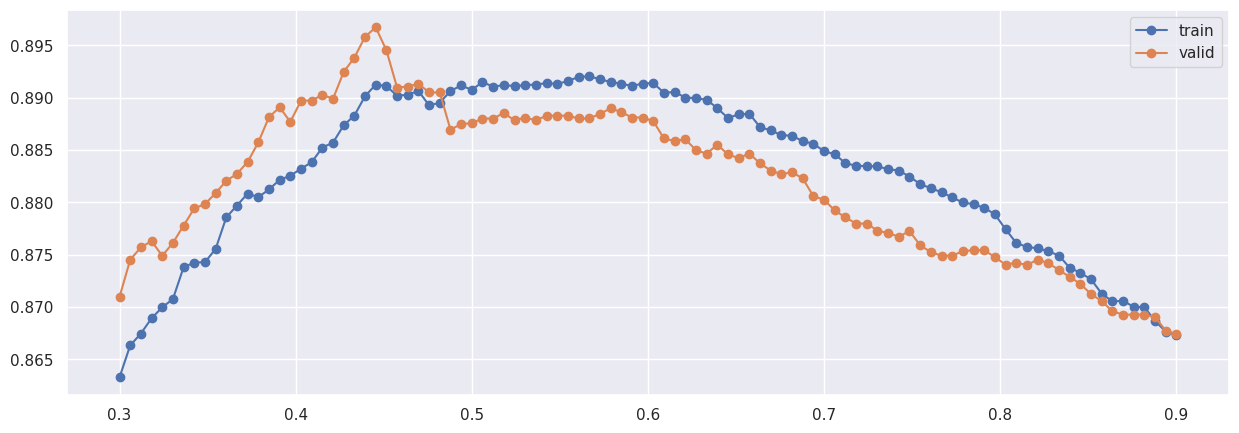

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(class_weigh_result['class_weight'], class_weigh_result['train_f1'], marker='o', label= 'train')
plt.plot(class_weigh_result['class_weight'], class_weigh_result['test_f1'], marker='o', label= 'valid')
plt.legend();

### Iteractions

In [ ]:
#  define function to get the n_estimators

def get_best_model(X_train, X_test, y_train, y_test, r_min=1, r_max= 100):

    results = []

    for n_iter in (range(r_min, r_max, 1)):

        F1_SCORE_TRAIN = []
        F1_SCORE_TEST = []
        x = {}
        # define the regressor model

        model = LogisticRegression(max_iter = n_iter,
                                   solver = 'liblinear',
                                   C = 1,
                                   class_weight={0:1-0.445455, 1:0.445455},
                                   random_state = 1727,
                                   verbose=False)

        # fit the model with the training data

        model.fit(X_train, y_train)

        # Appending F1 scores to empty list calculated using the predictions
        model_train = model.predict(X_train)
        model_test = model.predict(X_test)

        f1_score_train = f1_score(model_train,y_train)
        f1_score_test = f1_score(model_test,y_test)

        # get the rmsle on train and valid

        F1_SCORE_TRAIN.append(f1_score_train)
        F1_SCORE_TEST.append(f1_score_test)

        # calculate the mean F1 on train and valid data

        mean_f1_train = np.mean(F1_SCORE_TRAIN)
        mean_f1_test = np.mean(F1_SCORE_TEST)
        x['iterations'] = n_iter
        x['train_f1'] = mean_f1_train
        x['test_f1'] = mean_f1_test
        results.append(x)

        print('With N_ITERATIONS:\t'+ str(n_iter) + '\tMEAN F1 TRAIN:\t' + str(mean_f1_train)+ '\tMEAN F1 VALID: '+str(mean_f1_test))


    return pd.DataFrame.from_dict(results)

In [ ]:
# train model for n_estimators value 100 to 1800 with a gap of 100 estimators at each iteration.
best_result = get_best_model(inputs_train, inputs_test, y_train, y_test,r_min=1, r_max=40)

With N_ITERATIONS:	1	MEAN F1 TRAIN:	0.8754261225284893	MEAN F1 VALID: 0.8722741433021807
With N_ITERATIONS:	2	MEAN F1 TRAIN:	0.8772727272727273	MEAN F1 VALID: 0.8759873617693523
With N_ITERATIONS:	3	MEAN F1 TRAIN:	0.8788899091929395	MEAN F1 VALID: 0.874897792313982
With N_ITERATIONS:	4	MEAN F1 TRAIN:	0.8839103869653768	MEAN F1 VALID: 0.8839103869653768
With N_ITERATIONS:	5	MEAN F1 TRAIN:	0.8876611418047882	MEAN F1 VALID: 0.8917249897076986
With N_ITERATIONS:	6	MEAN F1 TRAIN:	0.8910243304027806	MEAN F1 VALID: 0.8967213114754098
With N_ITERATIONS:	7	MEAN F1 TRAIN:	0.8912510220768601	MEAN F1 VALID: 0.8967213114754098
With N_ITERATIONS:	8	MEAN F1 TRAIN:	0.8912510220768601	MEAN F1 VALID: 0.8967213114754098
With N_ITERATIONS:	9	MEAN F1 TRAIN:	0.8912510220768601	MEAN F1 VALID: 0.8967213114754098
With N_ITERATIONS:	10	MEAN F1 TRAIN:	0.8912510220768601	MEAN F1 VALID: 0.8967213114754098
With N_ITERATIONS:	11	MEAN F1 TRAIN:	0.8912510220768601	MEAN F1 VALID: 0.8967213114754098
With N_ITERATIONS:	1

In [ ]:
print(best_result[(best_result['test_f1']==best_result['test_f1'].max())]['iterations'].min()),
print(best_result[(best_result['test_f1']==best_result['test_f1'].max())]['test_f1'].max())

6
0.8967213114754098


La mejor opción es 6 iteraciones

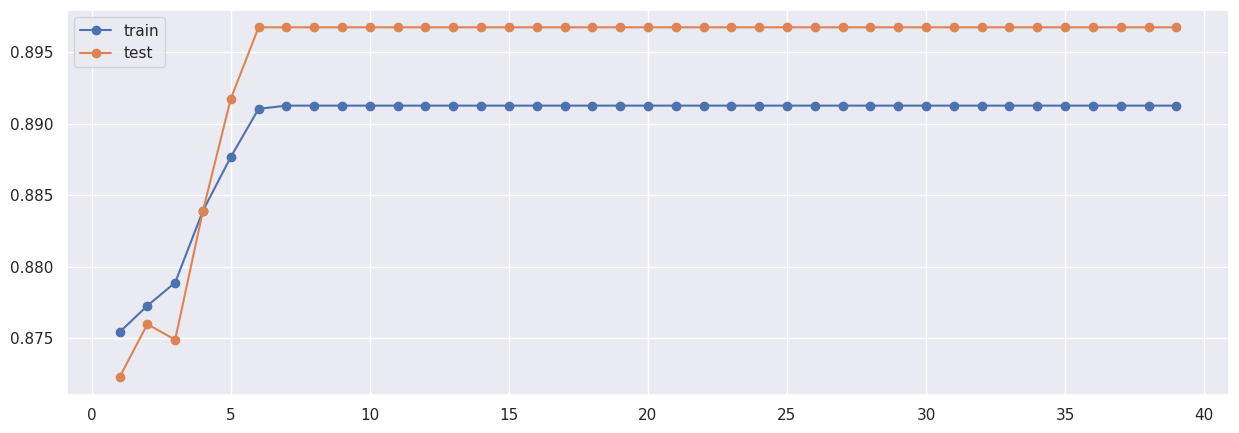

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(best_result['iterations'], best_result['train_f1'], marker='o', label= 'train')
plt.plot(best_result['iterations'], best_result['test_f1'], marker='o', label= 'test')
plt.legend();

---

## Modelo con p-valores

---

In [ ]:
reg3 = LogisticRegression_with_p_values(max_iter = 6,
                         solver = 'liblinear',
                         C = 1.0,
                         class_weight={0:1-0.445455, 1:0.445455},
                         random_state = 1727,
                         verbose=False)
# We create an instance of an object from the newly created 'LogisticRegression_with_p_values()' class.

In [ ]:
reg3.fit(inputs_train, y_train)

In [ ]:
# Same as above.
summary_table = pd.DataFrame(columns = ['Feature name'], data = feature_name)
summary_table['Coefficients'] = np.transpose(reg3.coef_)
summary_table.index = summary_table.index + 1
summary_table.loc[0] = ['Intercept', reg3.intercept_[0]]
summary_table = summary_table.sort_index()
#summary_table = summary_table.sort_values(by='Coefficients', ascending=False)
summary_table

,Feature name,Coefficients
0,Intercept,-5.216831
1,mora_de_30_60:0,0.238435
2,mora_de_60_90:0,0.105009
3,mora_mayor_90:0,0.258891
4,regional:DN,0.061974
5,regional:DS,0.322182
6,regional:OC,0.414924
7,unidad_negocio:GRN,0.262742
8,condicion_pago:08D,0.852955
9,condicion_pago:15D,0.563804


Ahora, guardamos los p-valores del modelo con los hiperparametros correctos

In [ ]:
# This is a list.
p_values = reg.p_values
# We take the result of the newly added method 'p_values' and store it in a variable 'p_values'.

In [ ]:
p_values = np.append(np.nan, np.array(p_values))
summary_table['p_values'] = p_values
summary_table

,Feature name,Coefficients,p_values
0,Intercept,-5.216831,NaN
1,mora_de_30_60:0,0.238435,3.631266e-02
2,mora_de_60_90:0,0.105009,5.415376e-02
3,mora_mayor_90:0,0.258891,3.094592e-02
4,regional:DN,0.061974,7.587931e-01
5,regional:DS,0.322182,7.991521e-03
6,regional:OC,0.414924,2.312778e-03
7,unidad_negocio:GRN,0.262742,8.833591e-03
8,condicion_pago:08D,0.852955,6.308709e-11
9,condicion_pago:15D,0.563804,6.735966e-05


---

## Métricas del Modelo

---

In [ ]:
reg2 = LogisticRegression(max_iter = 6,
                         solver = 'liblinear',
                         C = 1,
                         class_weight={0:1-0.445455, 1:0.445455},
                         random_state = 1727,
                         verbose=False)

In [ ]:
reg2.fit(inputs_train, y_train)

LogisticRegression(C=1, class_weight={0: 0.5545450000000001, 1: 0.445455},
                   max_iter=6, random_state=1727, solver='liblinear',
                   verbose=False)

In [ ]:
reg2.intercept_
# Displays the intercept contain in the estimated ("fitted") object from the 'LogisticRegression' class.

array([-5.21683071])

In [ ]:
reg2.coef_
# Displays the coefficients contained in the estimated ("fitted") object from the 'LogisticRegression' class.

array([[ 0.23843549,  0.10500855,  0.25889096,  0.06197379,  0.32218188,
         0.41492415,  0.26274167,  0.85295481,  0.5638043 ,  0.14997231,
         0.11767823,  0.96231094, -0.26134332,  0.23821626,  1.10026087,
         0.85210302,  1.85886743, -0.41175353,  2.41003025,  1.29767591,
         1.82058683,  0.85366777,  0.10955921, -0.57951691, -0.07286422,
        -0.03577253,  0.46025151,  0.4013295 ,  0.50384559,  0.98230572,
         1.46200696]])

In [ ]:
feature_name = inputs_train.columns.values
# Stores the names of the columns of a dataframe in a variable.

In [ ]:
summary_table = pd.DataFrame(columns = ['Feature name'], data = feature_name)
# Creates a dataframe with a column titled 'Feature name' and row values contained in the 'feature_name' variable.
summary_table['Coefficients'] = np.transpose(reg2.coef_)
# Creates a new column in the dataframe, called 'Coefficients',
# with row values the transposed coefficients from the 'LogisticRegression' object.
summary_table.index = summary_table.index + 1
# Increases the index of every row of the dataframe with 1.
summary_table.loc[0] = ['Intercept', reg2.intercept_[0]]
# Assigns values of the row with index 0 of the dataframe.
#summary_table = summary_table.sort_index()

# Ordena el DataFrame por los valores de los coeficientes en orden descendente
summary_table = summary_table.sort_values(by='Coefficients', ascending=False)
# Sorts the dataframe by index.
summary_table

,Feature name,Coefficients
19,porcentaje_h_30_60: entre 0 y 30,2.410030
17,porcentaje_h_60_90: entre 0 y 20,1.858867
21,antiguedad: menor a 6 meses,1.820587
31,porcentaje_h_1_30: entre 75 y 100,1.462007
20,porcentaje_h_30_60: entre 30 y 70,1.297676
15,unidad_negocio:ADM_CIL,1.100261
30,porcentaje_h_1_30: entre 50 y 75,0.982306
12,centro_operacion:MANIZALES,0.962311
22,antiguedad: entre 6 meses y 1 año,0.853668
8,condicion_pago:08D,0.852955


In [ ]:
# Realiza las predicciones en el conjunto de prueba
y_prediction = reg2.predict(inputs_test)

# Genera el informe de clasificación
print(classification_report(y_test, y_prediction))

              precision    recall  f1-score   support

           0       0.74      0.51      0.60       378
           1       0.85      0.94      0.90      1160

    accuracy                           0.84      1538
   macro avg       0.80      0.73      0.75      1538
weighted avg       0.83      0.84      0.82      1538



### Validación cruzada

La cross-validation o validación cruzada es un método que permite probar el rendimiento de un modelo predictivo de Machine Learning. Ver [link](https://datascientest.com/es/cross-validation-definicion-e-importancia)

- **K-folds:** permite garantizar que todas las observaciones de la serie de datos original tengan la oportunidad de aparecer en la serie de entrenamiento y en la serie de prueba. En caso de datos de entrada limitados, resulta uno de los mejores enfoques.

 - Primero se empieza separando la serie de datos de manera aleatoria en K folds. El procedimiento tiene un parámetro único llamado “K” que hace referencia al número de grupos en el se dividirá la muestra.

 - El valor de K no debe ser ni demasiado bajo ni demasiado alto y, por lo general, se elige un valor comprendido entre 5 y 10 en función de la envergadura de la serie de datos. Por ejemplo, si K=10, la serie de datos se dividirá en 10 partes.

 - Un valor K más alto lleva a un modelo con menos sesgo, pero una varianza demasiado amplia puede llevar a un ajuste excesivo. Un valor más bajo es prácticamente lo mismo que utilizar el método Train-Test Split.

 - Después se ajusta el modelo utilizando los folds K-1 (K menos 1). El modelo se valida usando el K-fold restante. Las puntuaciones y los errores se deben anotar.

 - El proceso se repite hasta que cada K-fold sirva dentro de la serie de entrenamiento. La media de las puntuaciones registradas es la métrica de rendimiento del modelo.

Este proceso se puede realizar de manera manual o con ayuda de las funciones cross_val_score y cross_val-predict de la librería Python de Scikit-Learn. La función cross_val_score indica la puntuación de cada fold de prueba, mientras que la función cross_val_predict indica la puntuación predicha para cada observación de la serie de datos de entrada cuando formaba parte de la serie de prueba.

In [ ]:
# 10 folds selected
kfold = KFold(n_splits=10, random_state=1727, shuffle=True)
results = cross_val_score(reg2, X=inputs_train, y= y_train, cv=kfold, scoring='f1')
results

array([0.87869521, 0.86638831, 0.90140845, 0.88591984, 0.8701973 ,
       0.902     , 0.90551181, 0.89025641, 0.88058152, 0.8998968 ])

In [ ]:
# mean and std
results.mean()*100, results.std()*100
print("Accuracy: %.3f%% (%.3f%%)" % (results.mean()*100, results.std()*100))

Accuracy: 88.809% (1.326%)


- **Validación cruzada estratificada:** Similar a la validación de K-folds, pero se asegura de que la proporción de clases en cada fold sea similar a la del conjunto de datos original, lo que es útil cuando se trata de clasificación desequilibrada.

Ver [link](https://nicolasurrego.medium.com/asegura-el-%C3%A9xito-de-tus-modelos-de-machine-learning-el-poder-de-la-validaci%C3%B3n-cruzada-701e7635e299#:~:text=Validaci%C3%B3n%20cruzada%20estratificada%3A%20Similar%20a,se%20trata%20de%20clasificaci%C3%B3n%20desequilibrada.)

In [ ]:
# define cross-validation criteria. RepeatedStratifiedKFold automatially takes care of the class imbalance while splitting
k_stratified = RepeatedStratifiedKFold(n_splits=10, random_state=1727, n_repeats=3)
scores = cross_val_score(reg2, X=inputs_train, y= y_train, scoring='f1', cv=k_stratified)
scores

array([0.88282828, 0.86902287, 0.8863869 , 0.89180991, 0.90030211,
       0.8997955 , 0.87474333, 0.8921466 , 0.89655172, 0.88484848,
       0.88888889, 0.87525562, 0.8969697 , 0.87640449, 0.89110889,
       0.89641026, 0.88090349, 0.89159068, 0.87900724, 0.8927477 ,
       0.87423935, 0.8902439 , 0.88414634, 0.90296221, 0.89208633,
       0.88706366, 0.88774459, 0.89252815, 0.88163265, 0.89002037])

#### GINI and AUROC

- El método más empleado para medir la desigualdad en una población es el **coeficiente de Gini**, una herramienta económica que compara los salarios y que fue creada por el estadístico italiano Corrado Gini.

  El coeficiente de Gini se mide en una escala de cero a uno, donde cero constituye a la igualdad perfecta en la que todos tienen los mismos ingresos y uno equivale a la desigualdad máxima, en la que una sola persona acumula todos los ingresos. Un valor de 0,5 indica que la distribución de rentas es igualitaria.

  Ver [link](https://www.unir.net/revista/ciencias-sociales/coeficiente-gini/)

- La **curva ROC (AUC)** es una medida de rendimiento para los problemas de clasificación en varios ajustes de umbral. La ROC es una curva de probabilidad y la AUC representa el grado o la medida de separabilidad. Indica cuánto es capaz el modelo de distinguir entre clases. Cuanto mayor sea la AUC, mejor será el modelo para predecir 0 clases como 0 y 1 clase como 1. Por analogía, cuanto mayor sea la AUC, mejor será el modelo para distinguir entre pacientes con la enfermedad y sin enfermedad.

  La curva ROC se representa con TPR contra FPR, donde TPR está en el eje y y FPR está en el eje x.

  ![Texto alternativo](https://miro.medium.com/v2/resize:fit:640/format:webp/1*pk05QGzoWhCgRiiFbz-oKQ.png)

  Ver [link](https://towardsdatascience.com/understanding-auc-roc-curve-68b2303cc9c5)

In [ ]:
AUROC = np.mean(scores)
GINI = 2*AUROC - 1

# print the mean AUROC score and Gini
print('Mean AUROC: %.4f' % (AUROC))
print('Gini: %.4f' % (GINI))

Mean AUROC: 0.8877
Gini: 0.7754


In [ ]:
def Val_score(K):
    '''
  takes range of n_neighbors as input
  returns Mean and Standard Deviation for each value of n_neighbors
  '''
    avg = []
    std = []

    for i in K:
        # Using train test split function
        train_x, test_x, train_y, test_y = train_test_split(inputs_train, y_train, train_size=0.8,
                                                         random_state= randint(0, i), stratify=y_train)
        kfold = KFold(n_splits=i, random_state=1235, shuffle=True)

        score = cross_val_score(reg2, X = train_x, y = train_y, cv = kfold)

    # adding mean to avg list
        avg.append(score.mean())

    # adding standard deviation to std list
        std.append(score.std())

    return avg, std

La función prueba diferentes valores de K (*número de particiones para validación cruzada*) y devuelve el promedio y la desviación estándar de las puntuaciones de validación cruzada para cada valor de K. Esto te permitirá evaluar cómo el modelo se comporta a medida que varía el número de particiones en la validación cruzada.

In [ ]:
# va a iterar entre 2 y 20
n = range(2,20)
mean, std = Val_score(n)

Text(0.5, 1.0, 'Mean Validation score')

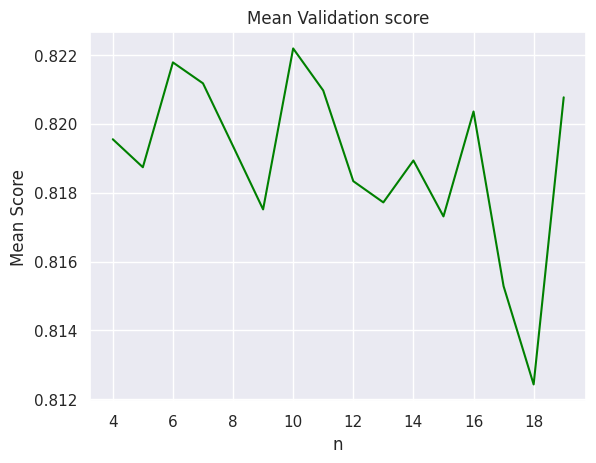

In [ ]:
plt.plot(n[2:20], mean[2:20], color = 'green', label = 'mean')
plt.xlabel('n')
plt.ylabel('Mean Score')
plt.title('Mean Validation score')

Text(0.5, 1.0, 'Standard Deviation of Validation score')

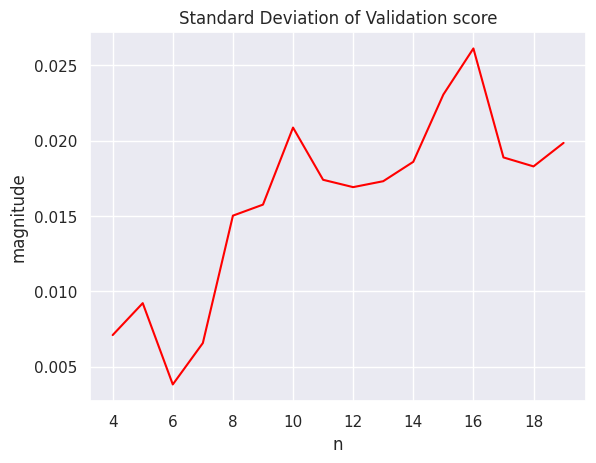

In [ ]:
plt.plot(n[2:20], std[2:20], color = 'red', label = 'Standard deviation')
plt.xlabel('n')
plt.ylabel('magnitude')
plt.title('Standard Deviation of Validation score')

### Confusion Matrix

  ![Texto alternativo](https://www.ibm.com/content/dam/connectedassets-adobe-cms/worldwide-content/creative-assets/s-migr/ul/g/c8/a7/binary-matrix.component.complex-narrative-xl.ts=1728993102148.png/content/adobe-cms/mx/es/topics/confusion-matrix/jcr:content/root/table_of_contents/body/content_section_styled/content-section-body/complex_narrative_390941229/items/content_group/image)

In [ ]:
test_predict = reg2.predict(inputs_test)
k = f1_score(test_predict, y_test)
print('Test f1_score    ', k )

Test f1_score     0.8967213114754098


In [ ]:
cf= confusion_matrix(y_test, test_predict)
print(cf)

[[ 192  186]
 [  66 1094]]


In [ ]:
print(confusion_matrix(y_test, test_predict, normalize='all'))

[[0.12483745 0.12093628]
 [0.04291287 0.71131339]]


Ver [link](https://www.ibm.com/content/dam/connectedassets-adobe-cms/worldwide-content/creative-assets/s-migr/ul/g/c8/a7/binary-matrix.component.complex-narrative-xl.ts=1728993102148.png/content/adobe-cms/mx/es/topics/confusion-matrix/jcr:content/root/table_of_contents/body/content_section_styled/content-section-body/complex_narrative_390941229/items/content_group/image)

- Accuracy: indica que tanto se está acertando.
- Precision: La precisión es la proporción de previsiones de clase positivas que realmente pertenecen a la clase en cuestión.
- Recall: indica la proporción de previsiones positivas para una clase dada de todas las instancias reales de esa clase. Dicha coincidencia también se conoce como sensibilidad o tasa de verdaderos positivos (TPR).

In [ ]:
recall = recall_score(y_test, test_predict)
precision = precision_score(y_test, test_predict)
acc = accuracy_score(y_test, test_predict)

print('Accuracy =' , acc)
print('Recall =' , recall)
print('Precision =' ,precision)

Accuracy = 0.8361508452535761
Recall = 0.9431034482758621
Precision = 0.8546875


In [ ]:
print(rep(y_test, test_predict))

              precision    recall  f1-score   support

           0       0.74      0.51      0.60       378
           1       0.85      0.94      0.90      1160

    accuracy                           0.84      1538
   macro avg       0.80      0.73      0.75      1538
weighted avg       0.83      0.84      0.82      1538



#### Accuracy and Area under the Curve AUC

In [ ]:
auc_score=roc_auc_score(y_test, test_predict)
print('AUC =' ,auc_score)

AUC = 0.725519978106185


La función get_reals tiene como objetivo calcular el valor de AUROC (también conocido como AUC, por sus siglas en inglés) para un modelo de clasificación binaria, evaluando cómo cambia el desempeño del modelo (en términos de AUROC) al variar el umbral (r) que se utiliza para clasificar las probabilidades predichas.

In [ ]:
#  define function to get the n_estimators
def get_reals(y_test, y_hat_test_proba):

    results = []
    real = list(np.linspace(0.2,0.9,100))

    for r in real:

        AUROC_TEST = []
        x = {}
        # define the regressor model

        df_actual_predicted_probs['y_hat_test'] = np.where(df_actual_predicted_probs['y_hat_test_proba'] > r, 1, 0)
        AUROC = roc_auc_score(df_actual_predicted_probs['y_test'], df_actual_predicted_probs['y_hat_test'])

        AUROC_TEST.append(AUROC)
        AUROC_TEST = np.mean(AUROC_TEST)

        x['real'] = r
        x['auroc'] = AUROC_TEST
        results.append(x)

        print('With the real number:\t'+ str(r) + '\tAUROC_TEST:\t' + str(AUROC_TEST))

    return pd.DataFrame.from_dict(results)

In [ ]:
y_hat_test_proba = reg2.predict_proba(inputs_test)
y_hat_test_proba = y_hat_test_proba[: ][: , 1]
y_test_temp = y_test.copy()
y_test_temp.reset_index(drop = True, inplace = True)
df_actual_predicted_probs = pd.concat([y_test_temp, pd.DataFrame(y_hat_test_proba)], axis = 1)

In [ ]:
df_actual_predicted_probs.columns = ['y_test', 'y_hat_test_proba']
df_actual_predicted_probs.index = y_test.index

In [ ]:
df_actual_predicted_probs.head()

,y_test,y_hat_test_proba
5618,1,0.894692
2390,1,0.889412
3820,1,0.907941
3871,1,0.974031
4701,1,0.802852


In [ ]:
# train model for n_estimators value 100 to 1800 with a gap of 100 estimators at each iteration.
best_real = get_reals(y_test, y_hat_test_proba)

With the real number:	0.2	AUROC_TEST:	0.57640713373472
With the real number:	0.20707070707070707	AUROC_TEST:	0.5790526363802226
With the real number:	0.21414141414141416	AUROC_TEST:	0.5790526363802226
With the real number:	0.22121212121212122	AUROC_TEST:	0.5843436416712279
With the real number:	0.22828282828282828	AUROC_TEST:	0.5856663929939793
With the real number:	0.23535353535353537	AUROC_TEST:	0.5900953293194673
With the real number:	0.24242424242424243	AUROC_TEST:	0.5914180806422186
With the real number:	0.2494949494949495	AUROC_TEST:	0.5940635832877212
With the real number:	0.25656565656565655	AUROC_TEST:	0.5976008027732165
With the real number:	0.26363636363636367	AUROC_TEST:	0.5984925196132093
With the real number:	0.27070707070707073	AUROC_TEST:	0.6046752417442073
With the real number:	0.2777777777777778	AUROC_TEST:	0.6055669585842001
With the real number:	0.28484848484848485	AUROC_TEST:	0.609535212552454
With the real number:	0.2919191919191919	AUROC_TEST:	0.6130724320379493


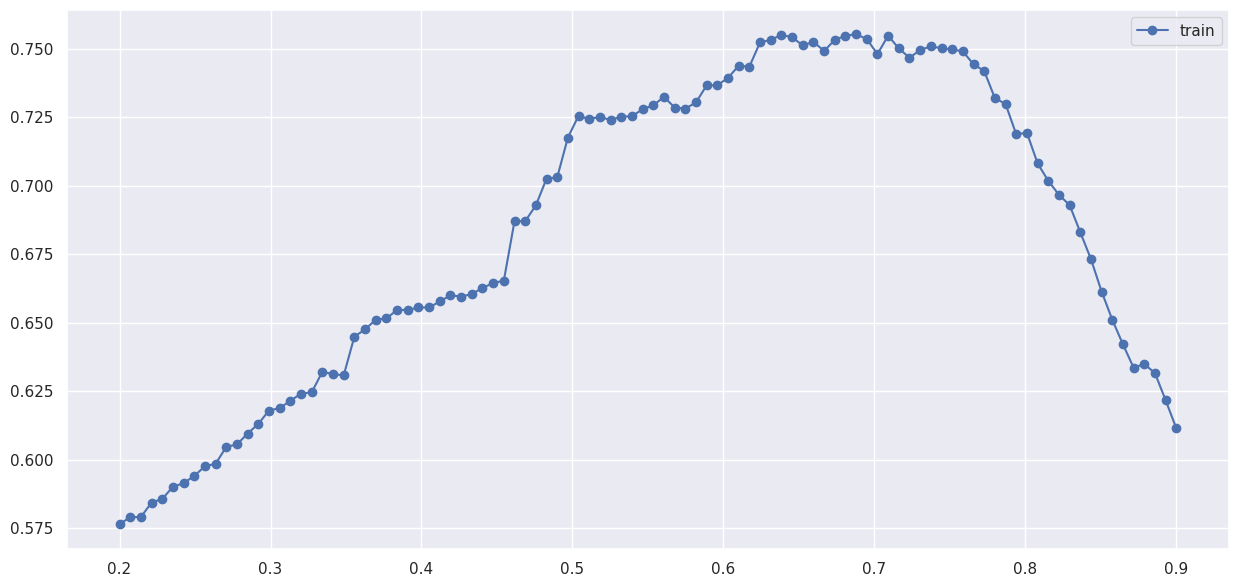

In [ ]:
plt.figure(figsize=(15,7))
plt.plot(best_real['real'], best_real['auroc'], marker='o', label= 'train')
plt.legend();

In [ ]:
best_real[best_real['auroc']==best_real['auroc'].max()]

,real,auroc
69,0.687879,0.75527


Con esto se podría ajustar el **thresholds** de la clasificación.

In [ ]:
tr = 0.687879
# We create a new column with an indicator,
# where every observation that has predicted probability greater than the threshold has a value of 1,
# and every observation that has predicted probability lower than the threshold has a value of 0.
df_actual_predicted_probs['y_hat_test'] = np.where(df_actual_predicted_probs['y_hat_test_proba'] > tr, 1, 0)

Previamente fue AUC = 0.725519978106185

In [ ]:
AUROC = roc_auc_score(df_actual_predicted_probs['y_test'], df_actual_predicted_probs['y_hat_test'])
# Calculates the Area Under the Receiver Operating Characteristic Curve (AUROC)
# from a set of actual values and their predicted probabilities.
AUROC

0.7552704798394454

In [ ]:
pd.crosstab(df_actual_predicted_probs['y_test'], df_actual_predicted_probs['y_hat_test'], rownames = ['Actual'], colnames = ['Predicted'])
# Creates a cross-table where the actual values are displayed by rows and the predicted values by columns.
# This table is known as a Confusion Matrix.

Predicted,0,1
Actual,,
0,265,113
1,221,939


In [ ]:
pd.crosstab(df_actual_predicted_probs['y_test'], df_actual_predicted_probs['y_hat_test'], rownames = ['Actual'], colnames = ['Predicted']) / df_actual_predicted_probs.shape[0]
# Here we divide each value of the table by the total number of observations,
# thus getting percentages, or, rates.

Predicted,0,1
Actual,,
0,0.172302,0.073472
1,0.143693,0.610533


In [ ]:
fpr, tpr, thresholds = roc_curve(df_actual_predicted_probs['y_test'], df_actual_predicted_probs['y_hat_test_proba'])

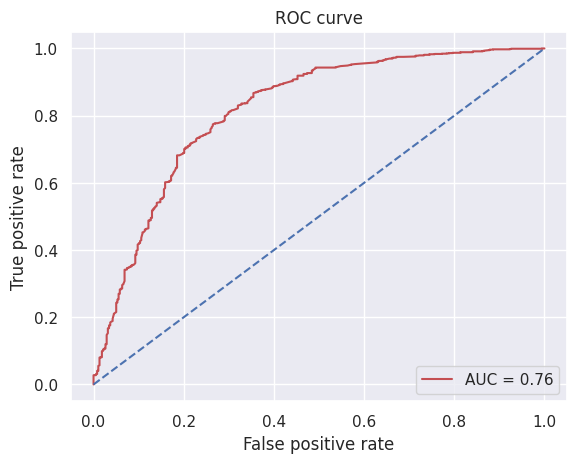

In [ ]:
plt.plot(fpr, tpr, color = 'r', label = 'AUC = %0.2f' % AUROC)
plt.legend(loc = 'lower right')
# We plot the false positive rate along the x-axis and the true positive rate along the y-axis,
# thus plotting the ROC curve.
plt.plot(fpr, fpr, linestyle = '--', color = 'b')

#plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
# We plot a seconary diagonal line, with dashed line style and black color.
plt.xlabel('False positive rate')
# We name the x-axis "False positive rate".
plt.ylabel('True positive rate')
# We name the x-axis "True positive rate".
plt.title('ROC curve');
# We name the graph "ROC curve".

No vale la pena hacer el cambio en tracehold al tenerse poca ganancia

#### Gini and Kolmogorov-Smirnov

In [ ]:
df_actual_predicted_probs = df_actual_predicted_probs.sort_values('y_hat_test_proba')
df_actual_predicted_probs = df_actual_predicted_probs.reset_index()

In [ ]:
df_actual_predicted_probs['Cumulative N Population'] = df_actual_predicted_probs.index + 1
# We calculate the cumulative number of all observations.
# We use the new index for that. Since indexing in ython starts from 0, we add 1 to each index.
df_actual_predicted_probs['Cumulative N Good'] = df_actual_predicted_probs['y_test'].cumsum()
# We calculate cumulative number of 'good', which is the cumulative sum of the column with actual observations.
df_actual_predicted_probs['Cumulative N Bad'] = df_actual_predicted_probs['Cumulative N Population'] - df_actual_predicted_probs['y_test'].cumsum()
# We calculate cumulative number of 'bad', which is
# the difference between the cumulative number of all observations and cumulative number of 'good' for each row.

In [ ]:
df_actual_predicted_probs['Cumulative Perc Population'] = df_actual_predicted_probs['Cumulative N Population'] / (df_actual_predicted_probs.shape[0])
# We calculate the cumulative percentage of all observations.
df_actual_predicted_probs['Cumulative Perc Good'] = df_actual_predicted_probs['Cumulative N Good'] / df_actual_predicted_probs['y_test'].sum()
# We calculate cumulative percentage of 'good'.
df_actual_predicted_probs['Cumulative Perc Bad'] = df_actual_predicted_probs['Cumulative N Bad'] / (df_actual_predicted_probs.shape[0] - df_actual_predicted_probs['y_test'].sum())
# We calculate the cumulative percentage of 'bad'.

In [ ]:
df_actual_predicted_probs.sample(5)

,index,y_test,y_hat_test_proba,y_hat_test,Cumulative N Population,Cumulative N Good,Cumulative N Bad,Cumulative Perc Population,Cumulative Perc Good,Cumulative Perc Bad
1492,675,1,0.964295,1,1493,1118,375,0.970741,0.963793,0.992063
699,7337,1,0.775946,1,700,392,308,0.455137,0.337931,0.814815
1028,4973,1,0.856792,1,1029,688,341,0.669051,0.593103,0.902116
1433,2264,1,0.949679,1,1434,1063,371,0.932380,0.916379,0.981481
1415,5398,0,0.943373,1,1416,1045,371,0.920676,0.900862,0.981481


In [ ]:
Gini = AUROC * 2 - 1
# Here we calculate Gini from AUROC.
Gini

0.5105409596788908

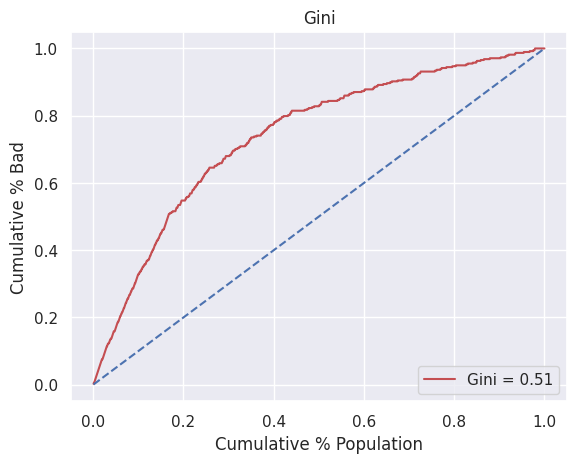

In [ ]:
# Plot Gini
plt.plot(df_actual_predicted_probs['Cumulative Perc Population'], df_actual_predicted_probs['Cumulative Perc Bad'], color = 'r', label = 'Gini = %0.2f' % Gini)
plt.legend(loc = 'lower right')
# We plot the cumulative percentage of all along the x-axis and the cumulative percentage 'good' along the y-axis,
# thus plotting the Gini curve.
plt.plot(df_actual_predicted_probs['Cumulative Perc Population'], df_actual_predicted_probs['Cumulative Perc Population'], linestyle = '--', color = 'b')
# We plot a seconary diagonal line, with dashed line style and black color.
plt.xlabel('Cumulative % Population')
# We name the x-axis "Cumulative % Population".
plt.ylabel('Cumulative % Bad')
# We name the y-axis "Cumulative % Bad".
plt.title('Gini');
# We name the graph "Gini".

Gini es una métrica de evaluación de modelos que mide la capacidad de discriminación de un modelo de clasificación. Se deriva de la curva ROC y tiene un rango de 0 a 1, donde valores más cercanos a 1 indican una mayor capacidad para diferenciar entre clases. En este caso, un valor de 0.51 sugiere que el modelo tiene una capacidad moderada para distinguir entre las clases, apenas mejor que un modelo aleatorio.

In [ ]:
KS = max(df_actual_predicted_probs['Cumulative Perc Bad'] - df_actual_predicted_probs['Cumulative Perc Good'])
# We calculate KS from the data. It is the maximum of the difference between the cumulative percentage of 'bad'
# and the cumulative percentage of 'good'.
KS

0.5144681627440247

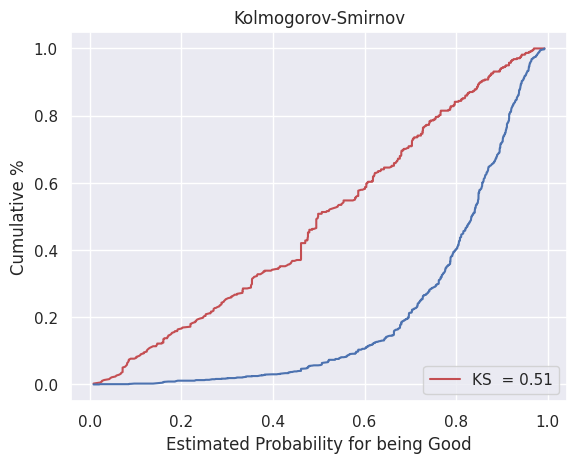

In [ ]:
# Plot KS
plt.plot(df_actual_predicted_probs['y_hat_test_proba'], df_actual_predicted_probs['Cumulative Perc Bad'], color = 'r', label = 'KS  = %0.2f' % KS)
plt.legend(loc = 'lower right')
# We plot the predicted (estimated) probabilities along the x-axis and the cumulative percentage 'bad' along the y-axis,
# colored in red.
plt.plot(df_actual_predicted_probs['y_hat_test_proba'], df_actual_predicted_probs['Cumulative Perc Good'], color = 'b')
# We plot the predicted (estimated) probabilities along the x-axis and the cumulative percentage 'good' along the y-axis,
# colored in red.
plt.xlabel('Estimated Probability for being Good')
# We name the x-axis "Estimated Probability for being Good".
plt.ylabel('Cumulative %')
# We name the y-axis "Cumulative %".
plt.title('Kolmogorov-Smirnov');
# We name the graph "Kolmogorov-Smirnov".

KS es una métrica que evalúa la separación entre las distribuciones acumuladas de las predicciones para las dos clases (positiva y negativa). Se interpreta como la distancia máxima entre estas dos curvas acumuladas. Un valor de 0.51 también sugiere una capacidad moderada para separar las clases. Generalmente, un valor por encima de 0.6 se considera aceptable, mientras que por debajo de 0.5 indica un desempeño insuficiente.

In [ ]:
print(rep(y_test, df_actual_predicted_probs['y_hat_test']))

              precision    recall  f1-score   support

           0       0.26      0.34      0.30       378
           1       0.76      0.69      0.73      1160

    accuracy                           0.60      1538
   macro avg       0.51      0.52      0.51      1538
weighted avg       0.64      0.60      0.62      1538



GINI y KS confirman que no vale la pena modificar el tracehold de nuestro modelo

In [ ]:
import pickle
# Here we export our model to a 'SAV' file with file name 'pd_model.sav'.
pickle.dump(reg2, open('pd_model.sav', 'wb'))

---

## Aplicando el modelo

---

In [ ]:
logreg = LogisticRegression_with_p_values(max_iter = 6,
                         solver = 'liblinear',
                         C = 1.0,
                         class_weight={0:1-0.445455, 1:0.445455},
                         random_state = 1727,
                         verbose=False)

logreg.fit(inputs_train, y_train)

In [ ]:
feature_name = inputs_train.columns.values

In [ ]:
# Same as above.
summary_table = pd.DataFrame(columns = ['Feature name'], data = feature_name)
summary_table['Coefficients'] = np.transpose(logreg.coef_)
summary_table.index = summary_table.index + 1
summary_table.loc[0] = ['Intercept', logreg.intercept_[0]]
summary_table = summary_table.sort_index()
summary_table

,Feature name,Coefficients
0,Intercept,-5.216831
1,mora_de_30_60:0,0.238435
2,mora_de_60_90:0,0.105009
3,mora_mayor_90:0,0.258891
4,regional:DN,0.061974
5,regional:DS,0.322182
6,regional:OC,0.414924
7,unidad_negocio:GRN,0.262742
8,condicion_pago:08D,0.852955
9,condicion_pago:15D,0.563804


In [ ]:
p_values = logreg.p_values
p_values = np.append(np.nan,np.array(p_values))
summary_table['p_values'] = p_values
summary_table

,Feature name,Coefficients,p_values
0,Intercept,-5.216831,NaN
1,mora_de_30_60:0,0.238435,1.322520e-01
2,mora_de_60_90:0,0.105009,6.115672e-01
3,mora_mayor_90:0,0.258891,8.887020e-02
4,regional:DN,0.061974,6.469124e-01
5,regional:DS,0.322182,2.435191e-02
6,regional:OC,0.414924,3.676377e-02
7,unidad_negocio:GRN,0.262742,1.257406e-01
8,condicion_pago:08D,0.852955,9.471401e-08
9,condicion_pago:15D,0.563804,2.015977e-03


In [ ]:
confusion_matrix(y_test, test_predict, normalize='all')

array([[0.12483745, 0.12093628],
       [0.04291287, 0.71131339]])

### Scorecard

In [ ]:
ref_categories

['mora_de_30_60:1',
 'mora_de_60_90:1',
 'mora_mayor_90:1',
 'regional:DC',
 'unidad_negocio:OTRO NEGOCIO',
 'centro_operacion:SIBERIA',
 'condicion_pago:30D_CTD',
 'porcentaje_h_60_90: entre 80 y 100',
 'porcentaje_h_30_60: entre 70 y 100',
 'antiguedad: entre 3 y 5 años',
 'porcentaje_h_1_30: entre 0 y 25']

In [ ]:
df_ref_categories = pd.DataFrame(ref_categories, columns = ['Feature name'])
# We create a new dataframe with one column. Its values are the values from the 'reference_categories' list.
# We name it 'Feature name'.
df_ref_categories['Coefficients'] = 0
# We create a second column, called 'Coefficients', which contains only 0 values.
df_ref_categories['p_values'] = np.nan
# We create a third column, called 'p_values', with contains only NaN values.
df_ref_categories

,Feature name,Coefficients,p_values
0,mora_de_30_60:1,0,NaN
1,mora_de_60_90:1,0,NaN
2,mora_mayor_90:1,0,NaN
3,regional:DC,0,NaN
4,unidad_negocio:OTRO NEGOCIO,0,NaN
5,centro_operacion:SIBERIA,0,NaN
6,condicion_pago:30D_CTD,0,NaN
7,porcentaje_h_60_90: entre 80 y 100,0,NaN
8,porcentaje_h_30_60: entre 70 y 100,0,NaN
9,antiguedad: entre 3 y 5 años,0,NaN


In [ ]:
df_scorecard = pd.concat([summary_table, df_ref_categories])
# Concatenates two dataframes.
df_scorecard = df_scorecard.reset_index()
# We reset the index of a dataframe.
df_scorecard

,index,Feature name,Coefficients,p_values
0,0,Intercept,-5.216831,NaN
1,1,mora_de_30_60:0,0.238435,1.322520e-01
2,2,mora_de_60_90:0,0.105009,6.115672e-01
3,3,mora_mayor_90:0,0.258891,8.887020e-02
4,4,regional:DN,0.061974,6.469124e-01
5,5,regional:DS,0.322182,2.435191e-02
6,6,regional:OC,0.414924,3.676377e-02
7,7,unidad_negocio:GRN,0.262742,1.257406e-01
8,8,condicion_pago:08D,0.852955,9.471401e-08
9,9,condicion_pago:15D,0.563804,2.015977e-03


In [ ]:
df_scorecard['Original feature name'] = df_scorecard['Feature name'].str.split(':').str[0]
# We create a new column, called 'Original feature name', which contains the value of the 'Feature name' column,
# up to the column symbol.
df_scorecard

,index,Feature name,Coefficients,p_values,Original feature name
0,0,Intercept,-5.216831,NaN,Intercept
1,1,mora_de_30_60:0,0.238435,1.322520e-01,mora_de_30_60
2,2,mora_de_60_90:0,0.105009,6.115672e-01,mora_de_60_90
3,3,mora_mayor_90:0,0.258891,8.887020e-02,mora_mayor_90
4,4,regional:DN,0.061974,6.469124e-01,regional
5,5,regional:DS,0.322182,2.435191e-02,regional
6,6,regional:OC,0.414924,3.676377e-02,regional
7,7,unidad_negocio:GRN,0.262742,1.257406e-01,unidad_negocio
8,8,condicion_pago:08D,0.852955,9.471401e-08,condicion_pago
9,9,condicion_pago:15D,0.563804,2.015977e-03,condicion_pago


In [ ]:
min_score = 150
max_score = 950

In [ ]:
df_scorecard.groupby('Original feature name')['Coefficients'].min()

,Coefficients
Original feature name,
Intercept,-5.216831
antiguedad,-0.579517
centro_operacion,-0.261343
condicion_pago,0.000000
mora_de_30_60,0.000000
mora_de_60_90,0.000000
mora_mayor_90,0.000000
porcentaje_h_1_30,0.000000
porcentaje_h_30_60,0.000000


In [ ]:
min_sum_coef = df_scorecard.groupby('Original feature name')['Coefficients'].min().sum()
# Up to the 'min()' method everything is the same as in te line above.
# Then, we aggregate further and sum all the minimum values.
min_sum_coef

-6.469444469890896

In [ ]:
df_scorecard.groupby('Original feature name')['Coefficients'].max()
# Groups the data by the values of the 'Original feature name' column.
# Aggregates the data in the 'Coefficients' column, calculating their maximum.

,Coefficients
Original feature name,
Intercept,-5.216831
antiguedad,1.820587
centro_operacion,0.962311
condicion_pago,0.852955
mora_de_30_60,0.238435
mora_de_60_90,0.105009
mora_mayor_90,0.258891
porcentaje_h_1_30,1.462007
porcentaje_h_30_60,2.410030


In [ ]:
max_sum_coef = df_scorecard.groupby('Original feature name')['Coefficients'].max().sum()
# Up to the 'min()' method everything is the same as in te line above.
# Then, we aggregate further and sum all the maximum values.
max_sum_coef

6.2674465221944295

In [ ]:
df_scorecard['Score - Calculation'] = df_scorecard['Coefficients'] * (max_score - min_score) / (max_sum_coef - min_sum_coef)
# We multiply the value of the 'Coefficients' column by the ration of the differences between
# maximum score and minimum score and maximum sum of coefficients and minimum sum of cefficients.
df_scorecard

,index,Feature name,Coefficients,p_values,Original feature name,Score - Calculation
0,0,Intercept,-5.216831,NaN,Intercept,-327.667448
1,1,mora_de_30_60:0,0.238435,1.322520e-01,mora_de_30_60,14.976056
2,2,mora_de_60_90:0,0.105009,6.115672e-01,mora_de_60_90,6.595553
3,3,mora_mayor_90:0,0.258891,8.887020e-02,mora_mayor_90,16.260857
4,4,regional:DN,0.061974,6.469124e-01,regional,3.892554
5,5,regional:DS,0.322182,2.435191e-02,regional,20.236140
6,6,regional:OC,0.414924,3.676377e-02,regional,26.061252
7,7,unidad_negocio:GRN,0.262742,1.257406e-01,unidad_negocio,16.502719
8,8,condicion_pago:08D,0.852955,9.471401e-08,condicion_pago,53.573815
9,9,condicion_pago:15D,0.563804,2.015977e-03,condicion_pago,35.412366


In [ ]:
df_scorecard['Score - Calculation'][0] = ((df_scorecard['Coefficients'][0] - min_sum_coef) / (max_sum_coef - min_sum_coef)) * (max_score - min_score) + min_score
# We divide the difference of the value of the 'Coefficients' column and the minimum sum of coefficients by
# the difference of the maximum sum of coefficients and the minimum sum of coefficients.
# Then, we multiply that by the difference between the maximum score and the minimum score.
# Then, we add minimum score.
df_scorecard

,index,Feature name,Coefficients,p_values,Original feature name,Score - Calculation
0,0,Intercept,-5.216831,NaN,Intercept,228.676265
1,1,mora_de_30_60:0,0.238435,1.322520e-01,mora_de_30_60,14.976056
2,2,mora_de_60_90:0,0.105009,6.115672e-01,mora_de_60_90,6.595553
3,3,mora_mayor_90:0,0.258891,8.887020e-02,mora_mayor_90,16.260857
4,4,regional:DN,0.061974,6.469124e-01,regional,3.892554
5,5,regional:DS,0.322182,2.435191e-02,regional,20.236140
6,6,regional:OC,0.414924,3.676377e-02,regional,26.061252
7,7,unidad_negocio:GRN,0.262742,1.257406e-01,unidad_negocio,16.502719
8,8,condicion_pago:08D,0.852955,9.471401e-08,condicion_pago,53.573815
9,9,condicion_pago:15D,0.563804,2.015977e-03,condicion_pago,35.412366


In [ ]:
df_scorecard['Score - Preliminary'] = df_scorecard['Score - Calculation'].round()
# We round the values of the 'Score - Calculation' column.
df_scorecard

,index,Feature name,Coefficients,p_values,Original feature name,Score - Calculation,Score - Preliminary
0,0,Intercept,-5.216831,NaN,Intercept,228.676265,229.0
1,1,mora_de_30_60:0,0.238435,1.322520e-01,mora_de_30_60,14.976056,15.0
2,2,mora_de_60_90:0,0.105009,6.115672e-01,mora_de_60_90,6.595553,7.0
3,3,mora_mayor_90:0,0.258891,8.887020e-02,mora_mayor_90,16.260857,16.0
4,4,regional:DN,0.061974,6.469124e-01,regional,3.892554,4.0
5,5,regional:DS,0.322182,2.435191e-02,regional,20.236140,20.0
6,6,regional:OC,0.414924,3.676377e-02,regional,26.061252,26.0
7,7,unidad_negocio:GRN,0.262742,1.257406e-01,unidad_negocio,16.502719,17.0
8,8,condicion_pago:08D,0.852955,9.471401e-08,condicion_pago,53.573815,54.0
9,9,condicion_pago:15D,0.563804,2.015977e-03,condicion_pago,35.412366,35.0


In [ ]:
max_sum_score_prel = df_scorecard.groupby('Original feature name')['Score - Preliminary'].max().sum()
# Groups the data by the values of the 'Original feature name' column.
# Aggregates the data in the 'Coefficients' column, calculating their maximum.
# Sums all maximum values.
max_sum_score_prel

950.0

In [ ]:
df_scorecard['Difference'] = df_scorecard['Score - Preliminary'] - df_scorecard['Score - Calculation']

In [ ]:
df_scorecard.sort_values(['Score - Preliminary'])

,index,Feature name,Coefficients,p_values,Original feature name,Score - Calculation,Score - Preliminary,Difference
24,24,antiguedad: entre 5 y 6 años,-0.579517,7.246687e-06,antiguedad,-36.399269,-36.0,0.399269
18,18,porcentaje_h_60_90: entre 20 y 80,-0.411754,1.721063e-01,porcentaje_h_60_90,-25.862106,-26.0,-0.137894
13,13,centro_operacion:VILLANUEVA_YUMBO_BELLO,-0.261343,9.173090e-02,centro_operacion,-16.414890,-16.0,0.414890
25,25,antiguedad: entre 6 y 8 años,-0.072864,4.916359e-01,antiguedad,-4.576578,-5.0,-0.423422
26,26,antiguedad: entre 8 y 10 años,-0.035773,8.145451e-01,antiguedad,-2.246861,-2.0,0.246861
42,10,porcentaje_h_1_30: entre 0 y 25,0.000000,NaN,porcentaje_h_1_30,0.000000,0.0,0.000000
36,4,unidad_negocio:OTRO NEGOCIO,0.000000,NaN,unidad_negocio,0.000000,0.0,0.000000
35,3,regional:DC,0.000000,NaN,regional,0.000000,0.0,0.000000
34,2,mora_mayor_90:1,0.000000,NaN,mora_mayor_90,0.000000,0.0,0.000000
33,1,mora_de_60_90:1,0.000000,NaN,mora_de_60_90,0.000000,0.0,0.000000


In [ ]:
df_scorecard['Score - Final'] = df_scorecard['Score - Preliminary']
#df_scorecard['Score - Final'][5] = 100  #### ?

In [ ]:
df_scorecard

,index,Feature name,Coefficients,p_values,Original feature name,Score - Calculation,Score - Preliminary,Difference,Score - Final
0,0,Intercept,-5.216831,NaN,Intercept,228.676265,229.0,0.323735,229.0
1,1,mora_de_30_60:0,0.238435,1.322520e-01,mora_de_30_60,14.976056,15.0,0.023944,15.0
2,2,mora_de_60_90:0,0.105009,6.115672e-01,mora_de_60_90,6.595553,7.0,0.404447,7.0
3,3,mora_mayor_90:0,0.258891,8.887020e-02,mora_mayor_90,16.260857,16.0,-0.260857,16.0
4,4,regional:DN,0.061974,6.469124e-01,regional,3.892554,4.0,0.107446,4.0
5,5,regional:DS,0.322182,2.435191e-02,regional,20.236140,20.0,-0.236140,20.0
6,6,regional:OC,0.414924,3.676377e-02,regional,26.061252,26.0,-0.061252,26.0
7,7,unidad_negocio:GRN,0.262742,1.257406e-01,unidad_negocio,16.502719,17.0,0.497281,17.0
8,8,condicion_pago:08D,0.852955,9.471401e-08,condicion_pago,53.573815,54.0,0.426185,54.0
9,9,condicion_pago:15D,0.563804,2.015977e-03,condicion_pago,35.412366,35.0,-0.412366,35.0


In [ ]:
df_scorecard['Score - Final'] = df_scorecard['Score - Final'].astype(int)

In [ ]:
df_scorecard[['Feature name','Score - Final']]

,Feature name,Score - Final
0,Intercept,229
1,mora_de_30_60:0,15
2,mora_de_60_90:0,7
3,mora_mayor_90:0,16
4,regional:DN,4
5,regional:DS,20
6,regional:OC,26
7,unidad_negocio:GRN,17
8,condicion_pago:08D,54
9,condicion_pago:15D,35


---

## Cut-offs

---

In [ ]:
df_cutoffs = pd.concat([pd.DataFrame(thresholds), pd.DataFrame(fpr), pd.DataFrame(tpr)], axis = 1)
# We concatenate 3 dataframes along the columns.

In [ ]:
df_cutoffs.columns = ['thresholds', 'fpr', 'tpr']

In [ ]:
df_cutoffs['thresholds'][0] = 1 - 1 / np.power(10, 16)

In [ ]:
df_cutoffs['Score'] = ((np.log(df_cutoffs['thresholds'] / (1 - df_cutoffs['thresholds'])) - min_sum_coef) * ((max_score - min_score) / (max_sum_coef - min_sum_coef)) + min_score).round().astype(int)

In [ ]:
df_cutoffs.head()

,thresholds,fpr,tpr,Score
0,1.000000,0.0,0.000000,2864
1,0.992968,0.0,0.001724,867
2,0.984642,0.0,0.005172,818
3,0.983667,0.0,0.007759,814
4,0.977474,0.0,0.018103,793


In [ ]:
df_cutoffs['Score'][0] = max_score
max_score

950

In [ ]:
df_cutoffs.head()

,thresholds,fpr,tpr,Score
0,1.000000,0.0,0.000000,950
1,0.992968,0.0,0.001724,867
2,0.984642,0.0,0.005172,818
3,0.983667,0.0,0.007759,814
4,0.977474,0.0,0.018103,793


In [ ]:
def n_approved(p):
    return np.where(df_actual_predicted_probs['y_hat_test_proba'] >= p, 1, 0).sum()

In [ ]:
df_cutoffs['N Approved'] = df_cutoffs['thresholds'].apply(n_approved)
# Assuming that all credit applications above a given probability of being 'good' will be approved,
# when we apply the 'n_approved' function to a threshold, it will return the number of approved applications.
# Thus, here we calculate the number of approved appliations for al thresholds.
df_cutoffs['N Rejected'] = df_actual_predicted_probs['y_hat_test_proba'].shape[0] - df_cutoffs['N Approved']
# Then, we calculate the number of rejected applications for each threshold.
# It is the difference between the total number of applications and the approved applications for that threshold.
df_cutoffs['Approval Rate'] = df_cutoffs['N Approved'] / df_actual_predicted_probs['y_hat_test_proba'].shape[0]
# Approval rate equalts the ratio of the approved applications and all applications.
df_cutoffs['Rejection Rate'] = 1 - df_cutoffs['Approval Rate']
# Rejection rate equals one minus approval rate.

In [ ]:
df_cutoffs['score_factor'] = pd.cut(df_cutoffs['Score'], 15)
df_cutoffs['score_factor_4'] = pd.cut(df_cutoffs['Score'], 4)
df_cutoffs['approval_rejection'] = np.where(df_cutoffs['N Approved']<df_cutoffs['N Rejected'], 1, 0)

<Axes: xlabel='Score', ylabel='Count'>

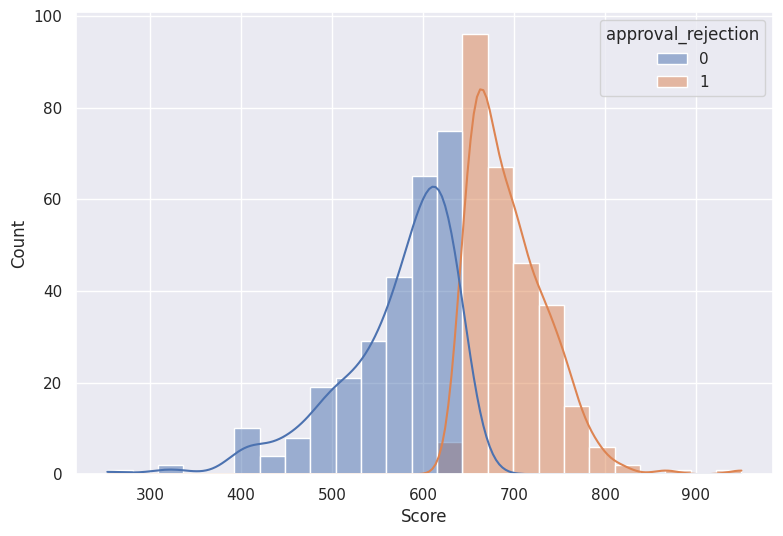

In [ ]:
plt.figure(figsize=(9,6))
sns.histplot(x= "Score", data=df_cutoffs, bins=25, hue="approval_rejection", kde=True)


In [ ]:
df_scorecard.to_csv('df_scorecard.csv')